In [10]:
import importlib
import pyro_bernoulli_rbm
importlib.reload(pyro_bernoulli_rbm)
from pyro_bernoulli_rbm import BernoulliRBM

In [11]:
from load_dataset import MNIST
from torch.utils.data import DataLoader, TensorDataset
import torch
from utils import create_dataloader
import time
import pyro
import pyro.distributions as dist


mnist = MNIST()
train_x, train_y, test_x, test_y = mnist.load_dataset(binary_status=False)
train_y = train_y/10.
print('MAE for all 0 selection:', torch.mean(train_x))

sample_size = 10000
batch_size = 100
epochs = 100
hidden_dim = 200
learning_rate = 0.1
epochs = 10

data_loader = create_dataloader(train_x[:sample_size], train_y[:sample_size], batch_size)
model = BernoulliRBM(hidden_dim, learning_rate)

MAE for all 0 selection: tensor(0.1307)


In [12]:
model.batch_fit(data_loader, epochs)

BernoulliRBM(hidden_dim=200, learning_rate=0.1)

In [14]:
latent_vars = []
labels = []
for X, y in data_loader:
    latent_vars.append(model.transform(X).detach().cpu())
    labels.append(y)
latent_vars = torch.cat(latent_vars, dim=0)
labels = torch.cat(labels, dim=0)
latent_dataset = TensorDataset(latent_vars, labels)
latent_loader = DataLoader(latent_dataset, batch_size, shuffle=False)

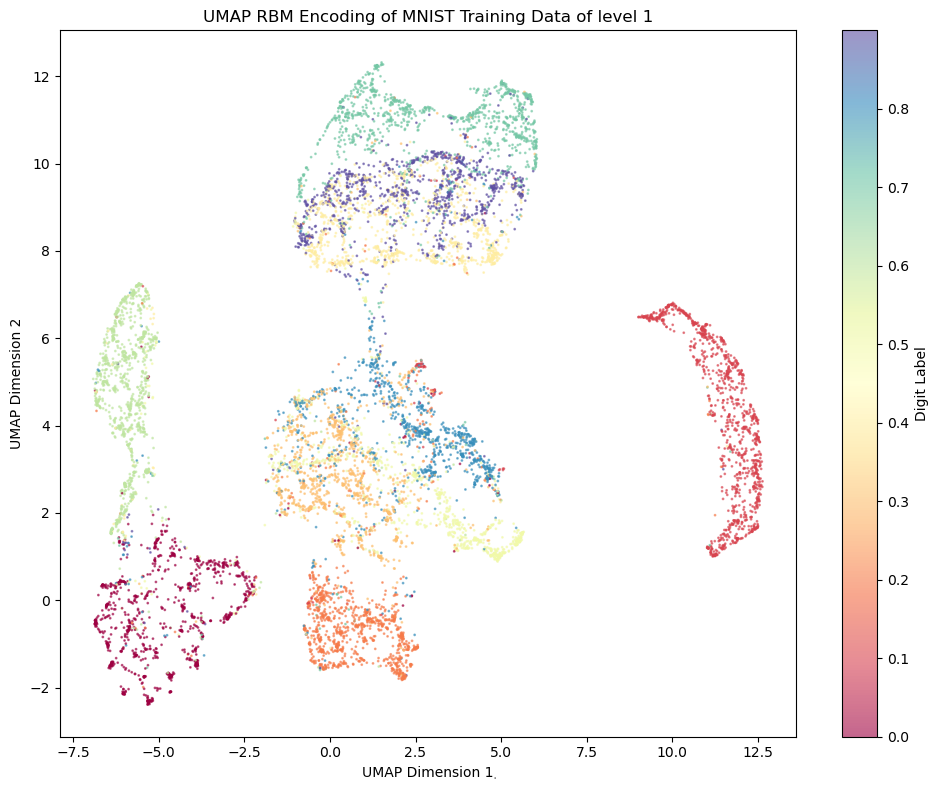

In [15]:
from utils import visualize_data

visualize_data(latent_loader, 1, '.', True)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap
import pyro
import pyro.distributions as dist
import numpy as np
from itertools import product


def all_same_length(*lists):
    lengths = list(map(len, lists))
    return all(length == lengths[0] for length in lengths)


def mix_weights(beta):
    beta1m_cumprod = (1 - beta).cumprod(-1)
    return F.pad(beta, (0, 1), value=1) * F.pad(beta1m_cumprod, (1, 0), value=1)


In [22]:
depth = 2
Cs = [2, 3]
def _gen_cluster_name(level, keyword):
    '''
    Generate cluster names for the nCRP and HDP processes.
    Parameters:
    ----------
    level: int
        level of the HDP or nCRP process
    keyword: str
        keyword to use for the cluster names (e.g. 'C' for nCRP, 'G' for HDP)
    -------
    Products:
    -------
    None
    -------
    Returns:
    -------
    list of str
        list of cluster names for the given level and keyword
    '''
    if level < 0 or level > depth:
        raise ValueError("Level out of range")
    if keyword not in ['C', 'G']:
        raise ValueError("Keyword must be 'C' or 'G'")
    levels = [list(range(1, Cs[l]+1)) for l in range(0, level)]
    result = [keyword + ''.join(map(str, items)) for items in product(*levels)]
    return result

In [11]:
CRPs = {}
level_CRPs = {}
etas = [1, 1]
def generate_nCRP():
    '''
    Generate the nCRP processes.
    Parameters:
    ----------
    None
    -------
    Products:
    -------
    self.CRPs: dict
        dictionary of nCRP processes
            key: str, category name
            value: torch.tensor(num_child_cat), child process weights of the category
    self.level_CRPs: dict
        dictionary of nCRP processes at each level
            key: str, level name
            value: torch.tensor(num_root_cat, ..., num_p_cat, num_c_cat), child process weights of the level
    -------
    Returns:
    -------
    None
    -------
    '''
    level_cats = list(np.cumprod(np.array(Cs)))
    level_cats.insert(0, 1)

    for level in range(depth):
        total_cat = level_cats[level]
        eta = etas[level]
        C = Cs[level]
        with pyro.plate(f"CRP_{level}", total_cat):
            cat_dist = pyro.sample(f"CRP_{level+1}", dist.Beta(1, eta).expand([C-1]).to_event(1))
        cat_names = _gen_cluster_name(level, 'C')
        child_dist = vmap(mix_weights)(cat_dist)
        CRPs.update(dict(zip(cat_names, child_dist)))
        level_CRPs[f"L{level}"] = child_dist.reshape(Cs[: level+1])
generate_nCRP()

In [12]:
CRPs

{'C': tensor([0.8299, 0.1701]),
 'C1': tensor([0.0542, 0.1259, 0.8200]),
 'C2': tensor([0.4884, 0.2494, 0.2622])}

In [13]:
level_CRPs

{'L0': tensor([0.8299, 0.1701]),
 'L1': tensor([[0.0542, 0.1259, 0.8200],
         [0.4884, 0.2494, 0.2622]])}

In [145]:
approx_CRPs = {}
approx_CRP_params = {}
def approximate_nCRP():
    '''
    Generate the nCRP processes.
    Parameters:
    ----------
    None
    -------
    Products:
    -------
    self.CRPs: dict
        dictionary of nCRP processes
            key: str, category name
            value: torch.tensor(num_child_cat), child process weights of the category
    self.level_CRPs: dict
        dictionary of nCRP processes at each level
            key: str, level name
            value: torch.tensor(num_root_cat, ..., num_p_cat, num_c_cat), child process weights of the level
    -------
    Returns:
    -------
    None
    -------
    '''
    level_cats = list(np.cumprod(np.array(Cs)))
    level_cats.insert(0, 1)

    for level in range(depth):
        total_cat = level_cats[level]
        C = Cs[level]
        params = pyro.param(f"zeta_{level}", lambda: dist.Uniform(0, 2).sample([total_cat, C-1]), constraint=constraints.positive)
        print(params.shape)
        cat_dist = pyro.sample(f"CRP_{level+1}", dist.Beta(torch.ones([total_cat, C-1]), params))
        cat_names = _gen_cluster_name(level, 'C')
        print(cat_dist.shape)
        child_dist = vmap(mix_weights)(cat_dist)
        approx_CRPs.update(dict(zip(cat_names, child_dist)))
        approx_CRP_params.update(dict(zip(cat_names, params)))
approximate_nCRP()

torch.Size([1, 2])
torch.Size([1, 2])
torch.Size([3, 1])
torch.Size([3, 1])


In [18]:
approx_CRPs

{'C': tensor([0.0297, 0.9703], grad_fn=<UnbindBackward0>),
 'C1': tensor([0.6902, 0.2181, 0.0917], grad_fn=<UnbindBackward0>),
 'C2': tensor([0.6975, 0.2592, 0.0433], grad_fn=<UnbindBackward0>)}

In [19]:
approx_CRP_params

{'C': tensor([0.1362, 1.5483], grad_fn=<UnbindBackward0>),
 'C1': tensor([1.5719, 0.7437, 0.5182], grad_fn=<UnbindBackward0>),
 'C2': tensor([1.2905, 0.6731, 0.6889], grad_fn=<UnbindBackward0>)}

In [23]:
K = 5
gamma = 1
alphas = [1, 1]
Gs = {}
level_Gs = {}

def generate_HDP():
    '''
    Generate the HDP processes.
    Parameters:
    ----------
    None
    -------
    Products:
    -------
    self.Gs: dict
        dictionary of HDP processes
            key: str, category name
            value: torch.tensor(K), mixture component weights of the category
    self.level_Gs: dict
        dictionary of HDP processes at each level
            key: str, level name
            value: torch.tensor(num_root_cat, ..., num_p_cat, num_c_cat, K), mixture component weights of the level
    -------
    Returns:
    -------
    None
    -------
    '''

    beta = pyro.param("beta", lambda: dist.Beta(1, gamma).sample([K-1]))
    Gs['G'] = mix_weights(beta)
    for level in range(depth):
        alpha =  alphas[level]
        process_names = _gen_cluster_name(level+1, 'G')
        level_G = []
        for child_p in process_names:
            parent_p = child_p[:-1]
            Gs[child_p] = pyro.sample(child_p, dist.Dirichlet(alpha*Gs[parent_p]))
            level_G.append(Gs[child_p])
        level_Gs[f"L{level}"] = torch.stack(level_G).reshape(Cs[: level+1] + [K])
generate_HDP()

In [24]:
Gs

{'G': tensor([0.1139, 0.0616, 0.0201, 0.5068, 0.2975], grad_fn=<MulBackward0>),
 'G1': tensor([8.0981e-03, 2.9527e-11, 4.1069e-08, 5.2279e-01, 4.6912e-01],
        grad_fn=<_DirichletBackward>),
 'G2': tensor([3.9044e-06, 2.4832e-10, 1.1755e-38, 9.9890e-01, 1.1006e-03],
        grad_fn=<_DirichletBackward>),
 'G11': tensor([1.1755e-38, 1.1755e-38, 1.1755e-38, 1.5319e-01, 8.4681e-01],
        grad_fn=<_DirichletBackward>),
 'G12': tensor([1.1755e-38, 1.1755e-38, 1.1755e-38, 4.9835e-01, 5.0165e-01],
        grad_fn=<_DirichletBackward>),
 'G13': tensor([1.2859e-20, 1.1755e-38, 1.1755e-38, 2.7205e-02, 9.7279e-01],
        grad_fn=<_DirichletBackward>),
 'G21': tensor([1.1755e-38, 1.1755e-38, 1.1755e-38, 1.0000e+00, 1.1755e-38],
        grad_fn=<_DirichletBackward>),
 'G22': tensor([1.1755e-38, 1.1755e-38, 1.1755e-38, 1.0000e+00, 1.1755e-38],
        grad_fn=<_DirichletBackward>),
 'G23': tensor([1.1755e-38, 1.1755e-38, 1.1755e-38, 1.0000e+00, 1.1755e-38],
        grad_fn=<_DirichletBackwa

In [25]:
level_Gs

{'L0': tensor([[8.0981e-03, 2.9527e-11, 4.1069e-08, 5.2279e-01, 4.6912e-01],
         [3.9044e-06, 2.4832e-10, 1.1755e-38, 9.9890e-01, 1.1006e-03]],
        grad_fn=<ViewBackward0>),
 'L1': tensor([[[1.1755e-38, 1.1755e-38, 1.1755e-38, 1.5319e-01, 8.4681e-01],
          [1.1755e-38, 1.1755e-38, 1.1755e-38, 4.9835e-01, 5.0165e-01],
          [1.2859e-20, 1.1755e-38, 1.1755e-38, 2.7205e-02, 9.7279e-01]],
 
         [[1.1755e-38, 1.1755e-38, 1.1755e-38, 1.0000e+00, 1.1755e-38],
          [1.1755e-38, 1.1755e-38, 1.1755e-38, 1.0000e+00, 1.1755e-38],
          [1.1755e-38, 1.1755e-38, 1.1755e-38, 1.0000e+00, 1.1755e-38]]],
        grad_fn=<ViewBackward0>)}

In [26]:
approx_Gs = {}
approx_G_params = {}
    
def approximate_HDP():
    '''
    Generate the HDP processes.
    Parameters:
    ----------
    None
    -------
    Products:
    -------
    self.Gs: dict
        dictionary of HDP processes
            key: str, category name
            value: torch.tensor(K), mixture component weights of the category
    self.level_Gs: dict
        dictionary of HDP processes at each level
            key: str, level name
            value: torch.tensor(num_root_cat, ..., num_p_cat, num_c_cat, K), mixture component weights of the level
    -------
    Returns:
    -------
    None
    -------
    '''

    for level in range(depth):
        process_names = _gen_cluster_name(level+1, 'G')
        for child_p in process_names:
            approx_G_params[child_p] = pyro.param(f"chi_{child_p}", lambda: dist.Uniform(0, 2).sample([K]), constraint=constraints.positive)
            approx_Gs[child_p] = pyro.sample(child_p, dist.Dirichlet(approx_G_params[child_p]))
approximate_HDP()

In [27]:
approx_Gs

{'G1': tensor([2.7925e-01, 1.5149e-02, 1.6798e-09, 4.1049e-01, 2.9512e-01],
        grad_fn=<_DirichletBackward>),
 'G2': tensor([7.5742e-01, 2.1828e-02, 9.7086e-02, 2.5686e-05, 1.2364e-01],
        grad_fn=<_DirichletBackward>),
 'G11': tensor([0.0996, 0.6797, 0.0272, 0.0709, 0.1226], grad_fn=<_DirichletBackward>),
 'G12': tensor([0.0872, 0.2080, 0.1455, 0.2315, 0.3279], grad_fn=<_DirichletBackward>),
 'G13': tensor([0.2948, 0.0677, 0.0255, 0.1917, 0.4204], grad_fn=<_DirichletBackward>),
 'G21': tensor([0.3370, 0.0645, 0.0488, 0.3832, 0.1664], grad_fn=<_DirichletBackward>),
 'G22': tensor([2.0676e-04, 1.3874e-01, 2.1642e-01, 7.5599e-02, 5.6903e-01],
        grad_fn=<_DirichletBackward>),
 'G23': tensor([0.5480, 0.2866, 0.0078, 0.1498, 0.0076], grad_fn=<_DirichletBackward>)}

In [66]:
pyro.clear_param_store()
H_r = dist.MultivariateNormal(torch.zeros(2), 3 * torch.eye(2))
H_c = dist.MultivariateNormal(torch.zeros(2), 3 * torch.eye(2))
def generate_mixture_components(H_c, H_r):
    '''
    Generate the mixture components for the regression and classification tasks.
    Parameters:
    ----------
    H_c: torch.distributions
        prior distribution for the classification mixture component
    H_r: torch.distributions
        prior distribution for the regression mixture component
    Products:
    -------
    self.mixture_components_c: torch.Tensor
        mixture components for classification
    self.mixture_components_r: torch.Tensor
        mixture components for regression
    -------
    Returns:
    -------
    None
    -------
    '''
    if not isinstance(H_c, pyro.distributions.Distribution) or not isinstance(H_r, pyro.distributions.Distribution):
        raise ValueError("H_c and H_r must be torch.distributions.Distribution objects")
    mixture_components_c = pyro.param(f"mixture_c", H_c.sample([K]))
    mixture_components_r = pyro.param(f"mixture_r", H_r.sample([K]))
    return mixture_components_c, mixture_components_r
m_c, m_r = generate_mixture_components(H_c, H_r)

In [67]:
m_c

tensor([[-0.0403,  0.0132],
        [-0.3207, -2.7496],
        [ 1.4930,  2.9138],
        [-4.6717, -1.0279],
        [ 0.3773, -0.5644]], requires_grad=True)

In [68]:
m_r

tensor([[-1.8415, -1.0817],
        [-1.2869, -0.9446],
        [ 4.0141,  2.0955],
        [ 2.2689,  0.1460],
        [ 2.6073,  2.3268]], requires_grad=True)

In [195]:
import importlib
import pyro_hdm
importlib.reload(pyro_hdm)
from pyro.infer import Predictive, SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap
import pyro
import pyro.distributions as dist
from itertools import product


def all_same_length(*lists):
    lengths = list(map(len, lists))
    return all(length == lengths[0] for length in lengths)


def mix_weights(beta):
    beta1m_cumprod = (1 - beta).cumprod(-1)
    return F.pad(beta, (0, 1), value=1) * F.pad(beta1m_cumprod, (1, 0), value=1)

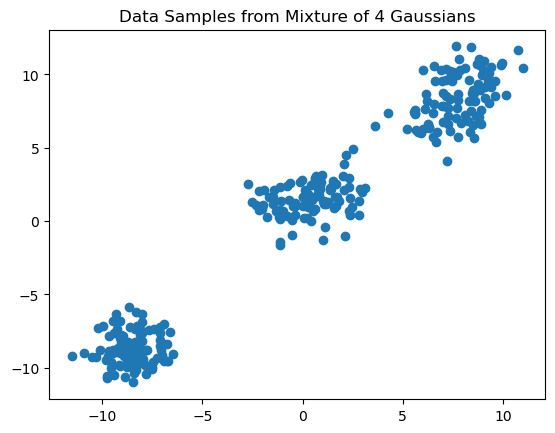

In [188]:
data = torch.cat((dist.MultivariateNormal(torch.tensor([8.5, 9.5]), torch.eye(2)).sample([50]),
                  dist.MultivariateNormal(torch.tensor([7., 7.]), torch.eye(2)).sample([50]),
                  dist.MultivariateNormal(torch.tensor([-9., -9.5]), torch.eye(2)).sample([50]),
                  dist.MultivariateNormal(torch.tensor([-8.5, -8.]), torch.eye(2)).sample([50]),
                  dist.MultivariateNormal(torch.tensor([1.5, 2]), torch.eye(2)).sample([50]),
                  dist.MultivariateNormal(torch.tensor([-0.5, 1]), torch.eye(2)).sample([50])))

plt.scatter(data[:, 0], data[:, 1])
plt.title("Data Samples from Mixture of 4 Gaussians")
plt.show()
N = data.shape[0]
label = torch.ones(N)

In [189]:
H_r = dist.MultivariateNormal(torch.zeros(2), 3 * torch.eye(2))
H_c = dist.MultivariateNormal(torch.zeros(2), 3 * torch.eye(2))
K = 6
gamma = 1
alphas = [1, 1]
etas = [1, 1]
Cs = [3, 2]

In [190]:
pyro.clear_param_store()
hdm_model = pyro_hdm.HDM(gamma, H_c, H_r, alphas, etas, K, Cs)
T = 6
optim = Adam({"lr": 0.05})
model = hdm_model.model
guide = hdm_model.guide
svi = SVI(model, guide, optim, loss=Trace_ELBO())
losses = []
def train(num_iterations):
    for j in tqdm(range(num_iterations)):
        loss = svi.step(data, label, N)
        losses.append(loss)

def truncate(alpha, centers, weights):
    threshold = alpha**-1 / 100.
    true_centers = centers[weights > threshold]
    true_weights = weights[weights > threshold] / torch.sum(weights[weights > threshold])
    return true_centers, true_weights

alpha = 0.1
n_iter = 1000
train(n_iter)

mixture_c: tensor([[ 0.1206, -3.9335],
        [-2.7663, -0.6136],
        [ 1.9222, -3.1966],
        [ 0.0821,  1.9786],
        [ 1.1682, -0.1379],
        [ 3.6050, -0.3899]], requires_grad=True)


100%|███████████████████████████████████████| 1000/1000 [00:22<00:00, 43.81it/s]


In [200]:
def truncate(params, centers, threshold=0.1):
    weights, _, _ = pyro_hdm.dirichlet_mean_variance(params)
    true_centers = centers[weights > threshold]
    true_weights = weights[weights > threshold] / torch.sum(weights[weights > threshold])
    return true_centers, true_weights
    

In [201]:
mix_weights(pyro.param("HDP_param_G").detach())

tensor([9.9536e-01, 4.6296e-03, 1.4372e-05, 3.9830e-08, 2.5839e-10, 4.6515e-12])

In [202]:
torch.sum(mix_weights(pyro.param("HDP_param_G").detach()))

tensor(1.)

In [204]:
truncate(mix_weights(pyro.param(f"HDP_param_G").detach()), pyro.param("mixture_c").detach())

(tensor([[ 0.1206, -3.9335]]), tensor([1.]))

Parameter of cat 1 tensor([9.7477, 9.8358, 0.9003, 0.7736, 0.8571, 0.9784])


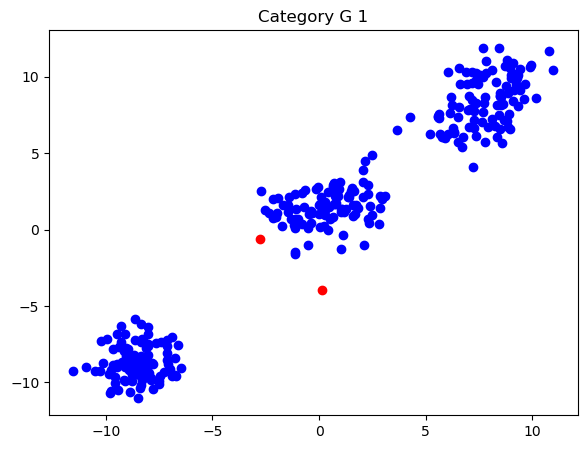

Parameter of cat 11 tensor([5.9457, 9.6523, 0.0256, 0.0160, 0.0167, 0.0135])


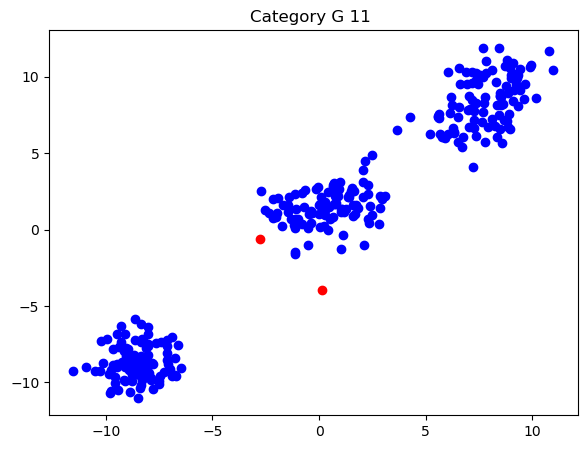

Parameter of cat 12 tensor([6.4226e+00, 9.6622e+00, 1.6905e-02, 1.3587e-02, 1.3858e-02, 7.7389e-03])


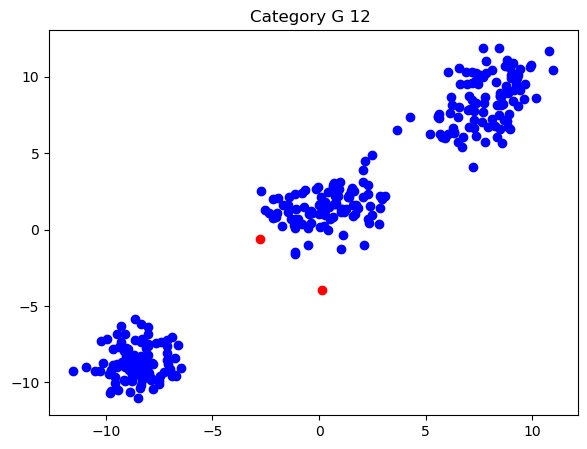

Parameter of cat 2 tensor([0.7875, 0.7228, 0.7037, 9.7771, 1.1765, 5.6455])


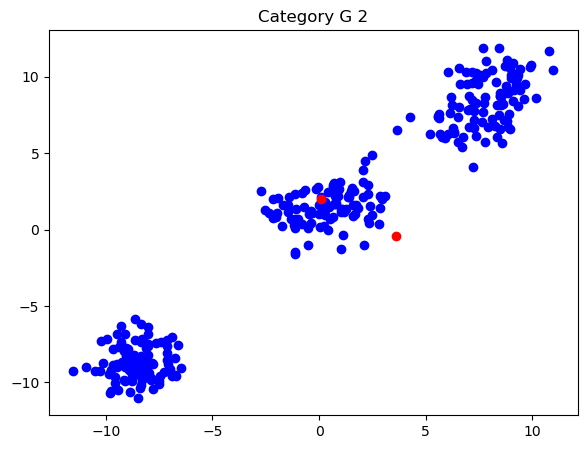

Parameter of cat 21 tensor([8.3879e-03, 1.8892e-02, 1.2339e-02, 9.7422e+00, 3.3079e-02, 8.9817e+00])


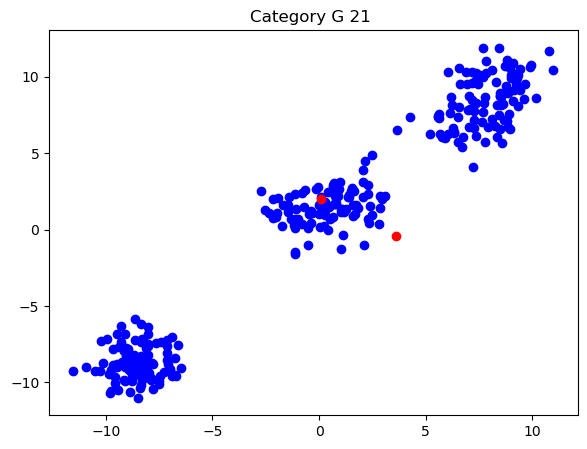

Parameter of cat 22 tensor([0.0170, 0.0204, 0.0206, 9.7812, 0.0531, 8.1153])


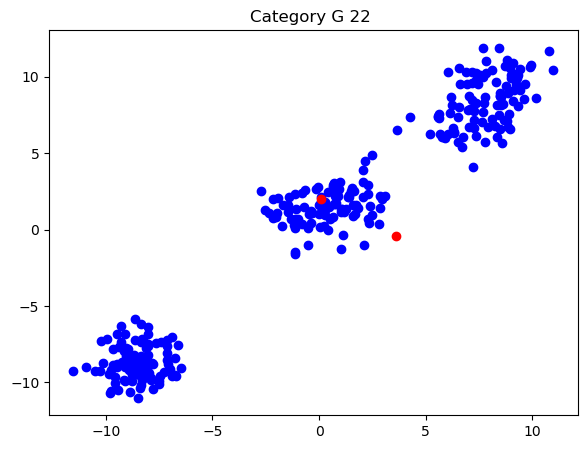

Parameter of cat 3 tensor([5.1505, 7.5913, 1.2075, 8.5809, 1.0324, 2.4003])


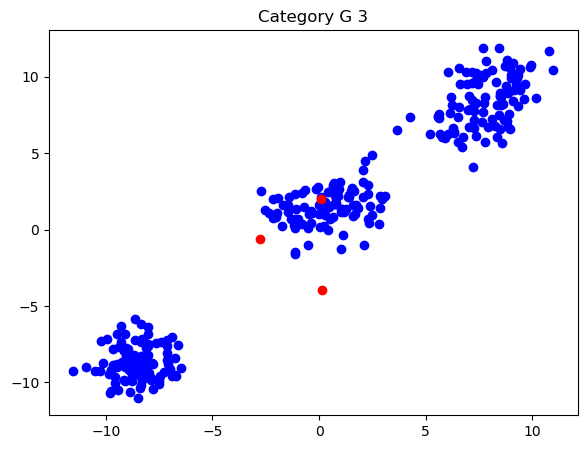

Parameter of cat 31 tensor([0.0375, 0.0685, 0.0188, 9.7381, 0.0360, 5.5681])


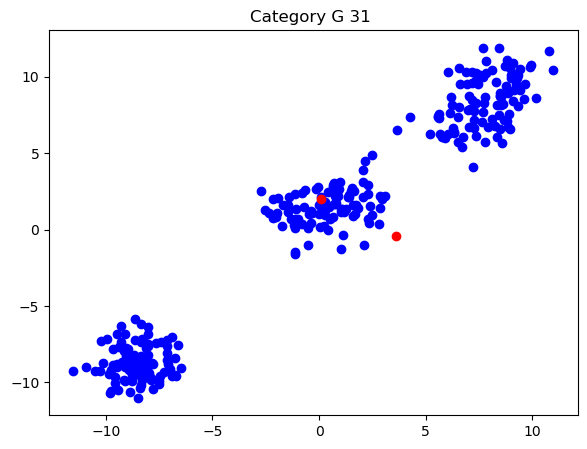

Parameter of cat 32 tensor([7.2807, 9.5476, 0.0178, 0.0778, 0.0127, 0.0312])


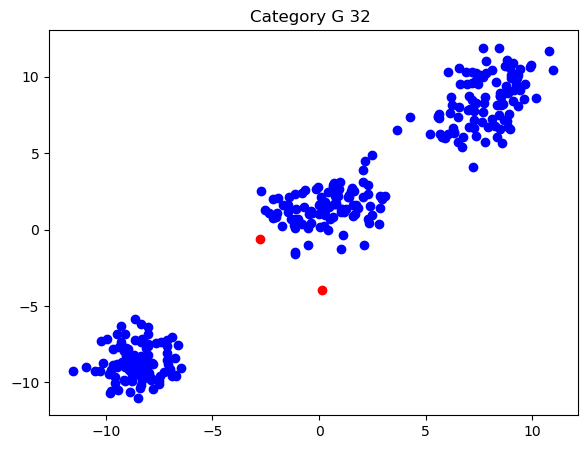

In [205]:
for i in range(1, Cs[0]+1):
    print(f"Parameter of cat {i}", pyro.param(f"HDP_param_G{i}").detach())
    Bayes_Centers, Bayes_Weights = truncate(pyro.param(f"HDP_param_G{i}").detach(), pyro.param("mixture_c").detach())

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(data[:, 0], data[:, 1], color="blue")
    plt.scatter(Bayes_Centers[:, 0], Bayes_Centers[:, 1], color="red")
    plt.title(f"Category G {i}")
    plt.show()
    for j in range(1, Cs[1]+1):
        print(f"Parameter of cat {i}{j}", pyro.param(f"HDP_param_G{i}{j}").detach())
        Bayes_Centers, Bayes_Weights = truncate(pyro.param(f"HDP_param_G{i}{j}").detach(), pyro.param("mixture_c").detach())
    
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.scatter(data[:, 0], data[:, 1], color="blue")
        plt.scatter(Bayes_Centers[:, 0], Bayes_Centers[:, 1], color="red")
        plt.title(f"Category G {i}{j} ")
        plt.show()

In [186]:
pyro.param("mixture_c").detach()

tensor([[-1.4587,  2.6997],
        [ 0.3435, -0.1003],
        [ 2.7549,  1.3778],
        [ 1.2012, -1.6642],
        [-2.5664, -2.0491],
        [-1.1519,  0.5654]])

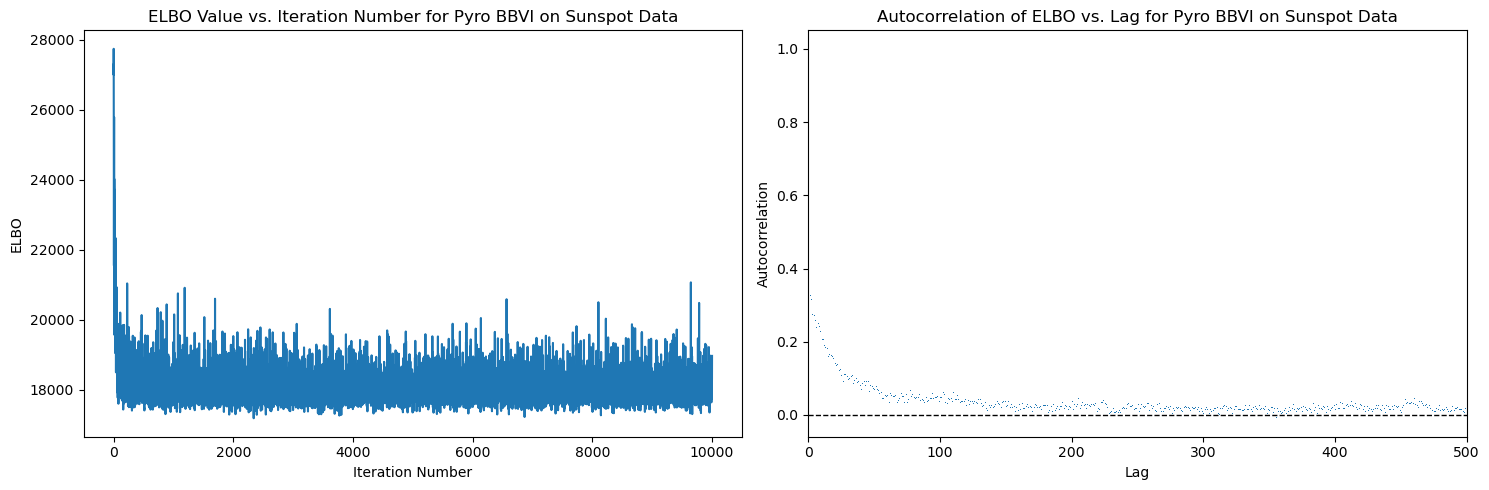

In [62]:
elbo_plot = plt.figure(figsize=(15, 5))

elbo_ax = elbo_plot.add_subplot(1, 2, 1)
elbo_ax.set_title("ELBO Value vs. Iteration Number for Pyro BBVI on Sunspot Data")
elbo_ax.set_ylabel("ELBO")
elbo_ax.set_xlabel("Iteration Number")
elbo_ax.plot(np.arange(n_iter), losses)

autocorr_ax = elbo_plot.add_subplot(1, 2, 2)
autocorr_ax.acorr(np.asarray(losses), detrend=lambda x: x - x.mean(), maxlags=750, usevlines=False, marker=',')
autocorr_ax.set_xlim(0, 500)
autocorr_ax.axhline(0, ls="--", c="k", lw=1)
autocorr_ax.set_title("Autocorrelation of ELBO vs. Lag for Pyro BBVI on Sunspot Data")
autocorr_ax.set_xlabel("Lag")
autocorr_ax.set_ylabel("Autocorrelation")
elbo_plot.tight_layout()
plt.show()